This notebook focuses on trying to find a way to segment cells within organoids properly.
The end goals is to segment cell and extract morphology features from cellprofiler.
These masks must be imported into cellprofiler to extract features.

## import libraries 

In [1]:
import argparse
import os
import pathlib
import sys

import matplotlib.pyplot as plt

# Import dependencies
import numpy as np
import skimage
import tifffile
import torch
from cellpose import models
from image_analysis_2D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_2D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_2D.file_utils.profiling_utils import (
    start_resource_profiling,
    stop_resource_profiling,
)
from skimage import io

root_dir, in_notebook = init_notebook()
image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [2]:
start_time, start_mem = start_resource_profiling()

## parse args and set paths

If as a notebook, then it will run the hardcoded paths.
However, if this is run as a script, the paths are set by the parsed arguments.

In [3]:
if not in_notebook:
    args_dict = parse_args()
    patient = args_dict["patient"]
    well_fov = args_dict["well_fov"]
    clip_limit = args_dict["clip_limit"]
    twoD_method = args_dict["twoD_method"]
    overwrite = args_dict.get("overwrite", False)
    check_for_missing_args(
        patient=patient,
        well_fov=well_fov,
        clip_limit=clip_limit,
        twoD_method=twoD_method,
    )
else:
    print("Running in a notebook")
    patient = "NF0037_T1"
    well_fov = "C4-2"
    clip_limit = 0.02
    twoD_method = "zmax"
    overwrite = True

if twoD_method == "zmax":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0a.zmax_proj/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0b.middle_slice/{well_fov}"
    ).resolve(strict=True)
elif twoD_method == "middle_n":
    input_dir = pathlib.Path(
        f"{image_base_dir}/data/{patient}/2D_analysis/0c.middle_n_slice_max_proj/{well_fov}"
    ).resolve(strict=True)
else:
    raise ValueError(f"Unknown twoD_method: {twoD_method}")

labels_path = input_dir / f"{well_fov}_nuclei_mask.tiff"

Running in a notebook


## Set up images, paths and functions

In [4]:
if overwrite or not labels_path.exists():
    image_extensions = {".tif", ".tiff"}
    files = sorted(input_dir.glob("*"))
    files = [str(x) for x in files if x.suffix in image_extensions]
    # get the nuclei image
    for f in files:
        if "405" in f:
            nuclei = io.imread(f)
    nuclei = np.array(nuclei)
    nuclei = skimage.exposure.equalize_adapthist(nuclei, clip_limit=clip_limit)

    use_GPU = torch.cuda.is_available()
    # Load the model
    model = models.CellposeModel(gpu=use_GPU)

    labels, details, _ = model.eval(nuclei)

    # save the labels
    tifffile.imwrite(labels_path, labels.astype(np.uint16))

/home/lippincm/4TB_A/NF1_2D_organoid_profiling_pipeline/.venv/lib/python3.13/site-packages/cellpose/dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:848.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


<Figure size 1000x500 with 0 Axes>

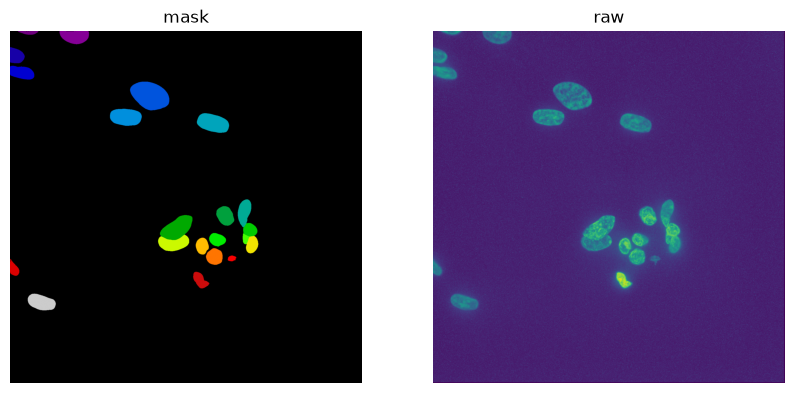

In [5]:
if in_notebook:
    plot = plt.figure(figsize=(10, 5))
    plt.figure(figsize=(10, 10))
    plt.subplot(121)
    plt.imshow(labels, cmap="nipy_spectral")
    plt.title("mask")
    plt.axis("off")

    plt.subplot(122)
    plt.imshow(nuclei, cmap="viridis")
    plt.title("raw")
    plt.axis("off")
    plt.show()

In [6]:
# this calls to stop profiling and cellects information about the run
# and associates metadata with the run by collecting it in the args

stop_resource_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="nuclei",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{input_dir.parent}/run_stats/{well_fov}_nuclei_segmentation.parquet"
    ),  # write path for the run stats parquet file
)


        Memory and time profiling for the run:
        Patient ID: NF0037_T1
        Well and FOV: C4-2
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 190.11 MB
        Current memory (tracemalloc): 79.48 MB
        RSS at end: 2437.62 MB
        Time elapsed:
        --- 21.19 seconds ---
        --- 0.35 minutes ---
        --- 0.01 hours ---
    


True